EM segmentation finished
Means: [ 82.75285641 128.88767293 168.49495358 207.98901253]
PSNR: 28.84 dB
SSIM: 0.8759
Entropy Change: -3.1472
Percent Change in Entropy: -43.30%


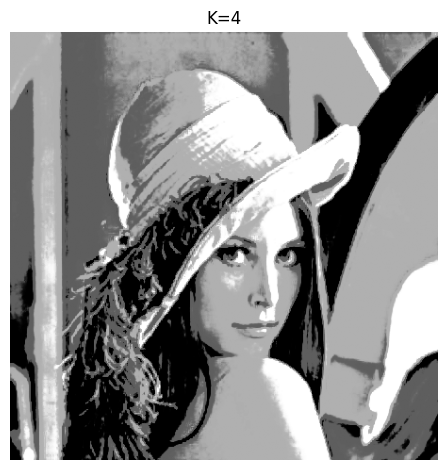

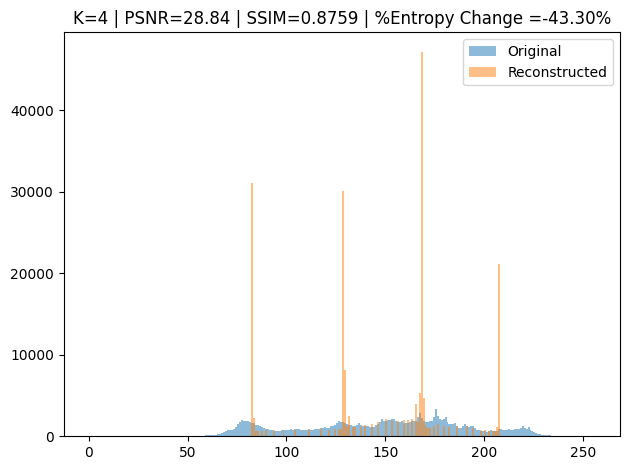

In [5]:
from GaussianKraus_EM import QuantumSegmentationEM as QS
image = r"/content/The-256-256-Lena-image.png"

QS = QS(image)
QS.run_segmentation(k_clusters= 4, sharpening_gamma=2.0)
metrics = QS.calculate_metrics()
print(f"PSNR: {metrics['PSNR']:.2f} dB")
print(f"SSIM: {metrics['SSIM']:.4f}")
print(f"Entropy Change: {metrics['Entropy Change']:.4f}")
print(f"Percent Change in Entropy: {metrics['Percent Change']:.2f}%")
QS.plot_images()
QS.plot_results()


Processing: /content/WhatsApp Image 2026-03-14 at 9.38.16 PM.jpeg
EM segmentation finished
Means: [ 34.40446883  97.86526202 151.88865527 200.53392189]
PSNR: 25.88 dB
SSIM: 0.7837
Entropy Change: -3.3826
Percent Change in Entropy: -43.51%


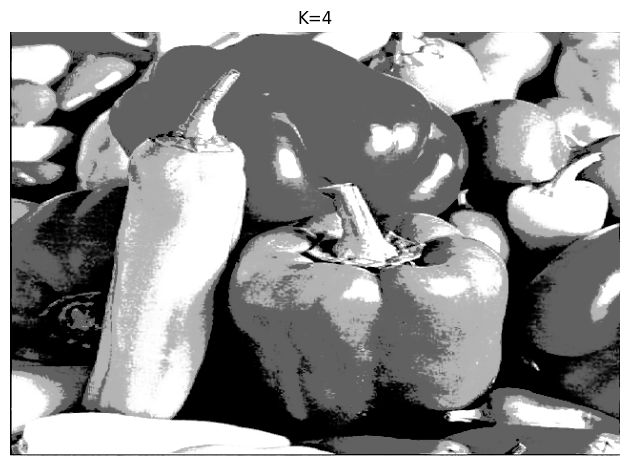

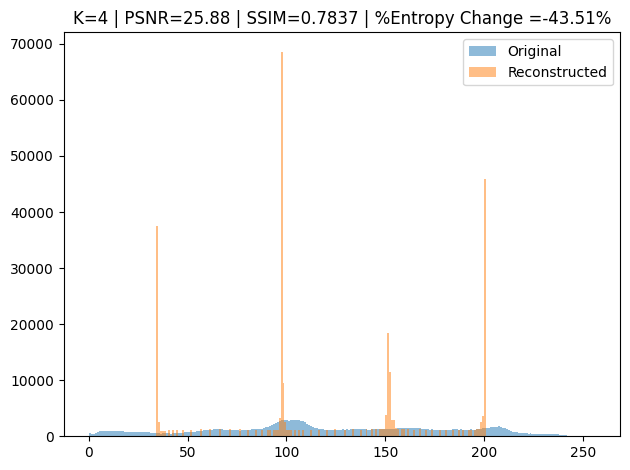


Processing: /content/WhatsApp Image 2026-03-14 at 9.38.17 PM (1).jpeg
EM segmentation finished
Means: [ 46.8233474   97.813326   143.38815968 184.0911529 ]
PSNR: 27.67 dB
SSIM: 0.8420
Entropy Change: -3.0312
Percent Change in Entropy: -40.61%


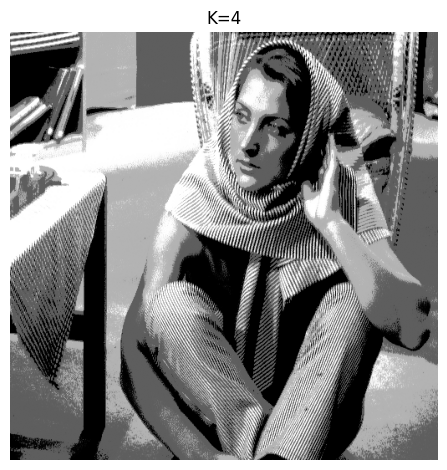

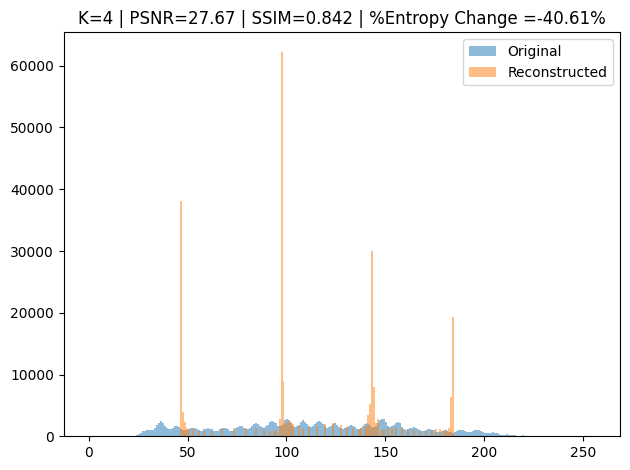

In [6]:
from GaussianKraus_EM import QuantumSegmentationEM as QS

# List of additional images to process
image_paths = [
    "/content/WhatsApp Image 2026-03-14 at 9.38.16 PM.jpeg",
    "/content/WhatsApp Image 2026-03-14 at 9.38.17 PM (1).jpeg"
]

for path in image_paths:
    print(f"\nProcessing: {path}")
    try:
        # Initialize and run segmentation
        seg_engine = QS(path)
        seg_engine.run_segmentation(k_clusters=4, sharpening_gamma=2.0)

        # Calculate and print metrics
        metrics = seg_engine.calculate_metrics()
        print(f"PSNR: {metrics['PSNR']:.2f} dB")
        print(f"SSIM: {metrics['SSIM']:.4f}")
        print(f"Entropy Change: {metrics['Entropy Change']:.4f}")
        print(f"Percent Change in Entropy: {metrics['Percent Change']:.2f}%")

        # Plot results
        seg_engine.plot_images()
        seg_engine.plot_results()
    except Exception as e:
        print(f"Error processing {path}: {e}")

Processing and saving results for: lena
EM segmentation finished
Means: [ 82.75285641 128.88767293 168.49495358 207.98901253]


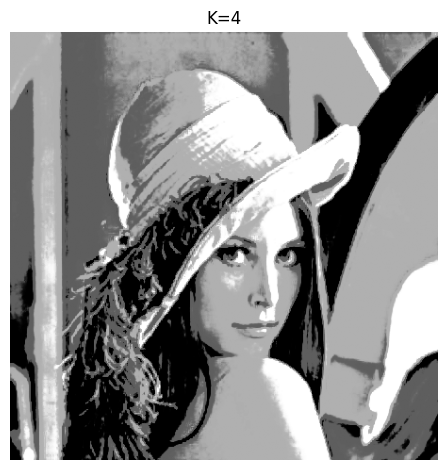

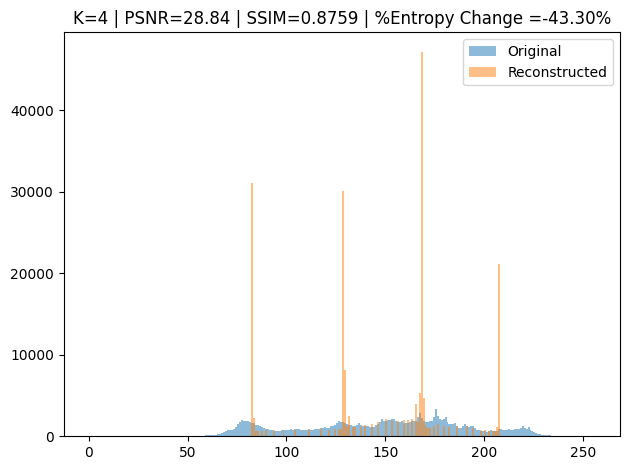

Processing and saving results for: whatsapp_1
EM segmentation finished
Means: [ 34.40446883  97.86526202 151.88865527 200.53392189]


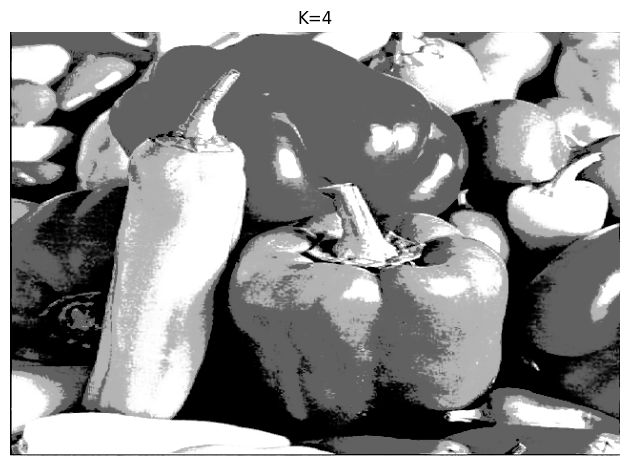

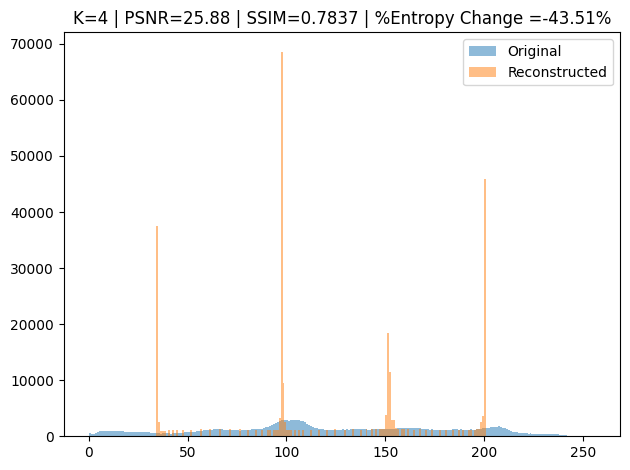

Processing and saving results for: whatsapp_2
EM segmentation finished
Means: [ 46.8233474   97.813326   143.38815968 184.0911529 ]


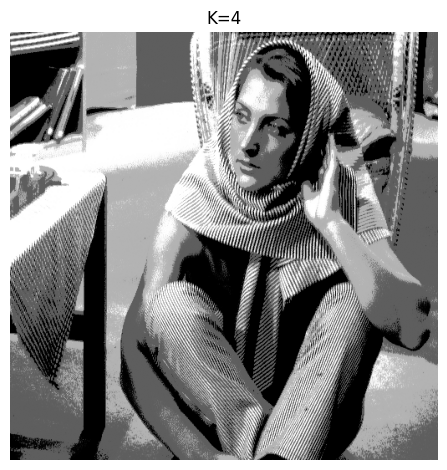

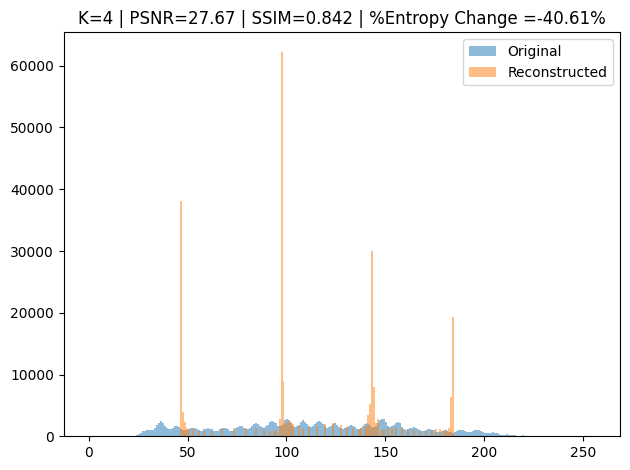

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import matplotlib.pyplot as plt
from google.colab import files
from GaussianKraus_EM import QuantumSegmentationEM as QS
import os

# Define images to process
images = [
    ("/content/The-256-256-Lena-image.png", "lena"),
    ("/content/WhatsApp Image 2026-03-14 at 9.38.16 PM.jpeg", "whatsapp_1"),
    ("/content/WhatsApp Image 2026-03-14 at 9.38.17 PM (1).jpeg", "whatsapp_2")
]

saved_files = []

for path, label in images:
    if os.path.exists(path):
        print(f"Processing and saving results for: {label}")
        seg = QS(path)
        seg.run_segmentation(k_clusters=4, sharpening_gamma=2.0)

        # Save Segmentation Comparison Plot
        seg.plot_images()
        img_name = f"{label}_segmentation.png"
        plt.savefig(img_name)
        saved_files.append(img_name)
        plt.close()

        # Save Histogram/Results Plot
        seg.plot_results()
        res_name = f"{label}_results.png"
        plt.savefig(res_name)
        saved_files.append(res_name)
        plt.close()

# Trigger download for all saved PNGs
for f in saved_files:
    files.download(f)